In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import joblib

##### Bước 1: Làm sạch new_data.csv (giống 01_cleaning_raw_data.ipynb)

In [7]:
work_dir = Path('data')
csv_path = work_dir / 'new_data.csv'

df = pd.read_csv(csv_path, skiprows=3)
print(f"Kích thước: {df.shape[0]} hàng × {df.shape[1]} cột")

# Loại bỏ các hàng có toàn bộ giá trị NaN (trừ cột time)
cols_to_check = [col for col in df.columns if col != 'time']
df_copy = df.dropna(subset=cols_to_check, how='all')

# Loại bỏ các cột có chứa giá trị NaN
df_copy = df_copy.dropna(axis=1)

# Chuyển time thành datetime, tách thêm cột day/month/year/hour
df_copy['time'] = pd.to_datetime(df_copy['time'])
df_copy['day'] = df_copy['time'].dt.day
df_copy['month'] = df_copy['time'].dt.month
df_copy['year'] = df_copy['time'].dt.year
df_copy['hour'] = df_copy['time'].dt.hour

cols = df_copy.columns.tolist()
time_idx = cols.index('time')
cols = cols[:time_idx + 1] + ['day', 'month', 'year', 'hour'] + \
    [c for c in cols[time_idx + 1:] if c not in ['day', 'month', 'year', 'hour']]
df_copy = df_copy[cols]
df_copy.reset_index(drop=True, inplace=True)

df_copy

Kích thước: 696 hàng × 11 cột


,time,day,month,year,hour,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky ()
0,2026-07-27 00:00:00,27,7,2026,0,12.5,11.0,250.0,6.0,3.1,40.0,0.18,2.0,0.0,0.0
1,2026-07-27 01:00:00,27,7,2026,1,10.6,9.5,205.0,5.4,2.6,39.0,0.18,2.0,0.0,0.0
2,2026-07-27 02:00:00,27,7,2026,2,8.9,7.9,187.0,4.8,2.3,39.0,0.18,2.0,0.0,0.0
3,2026-07-27 03:00:00,27,7,2026,3,7.8,7.0,182.0,4.2,2.1,41.0,0.17,1.0,0.0,0.0
4,2026-07-27 04:00:00,27,7,2026,4,7.1,6.4,180.0,3.7,2.0,44.0,0.16,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691,2026-08-24 19:00:00,24,8,2026,19,20.0,12.3,140.0,2.6,1.5,46.0,0.26,11.0,0.0,0.0
692,2026-08-24 20:00:00,24,8,2026,20,19.4,12.4,138.0,2.5,1.5,45.0,0.25,9.0,0.0,0.0
693,2026-08-24 21:00:00,24,8,2026,21,18.0,11.7,132.0,2.4,1.4,44.0,0.22,7.0,0.0,0.0
694,2026-08-24 22:00:00,24,8,2026,22,13.7,9.3,127.0,2.3,1.4,44.0,0.19,5.0,0.0,0.0


##### Kiểm tra tính liên tục của thời gian (cách đều 1 giờ)

In [8]:
def check_continuous_time(df):
    time_series = pd.to_datetime(df['time'])
    time_diff = time_series.diff()
    expected_diff = pd.Timedelta(hours=1)
    return (time_diff.iloc[1:] == expected_diff).all()


print("Dữ liệu liên tục theo giờ:", check_continuous_time(df_copy))

Dữ liệu liên tục theo giờ: True


##### Lưu new_data đã làm sạch

In [9]:
output_path = work_dir / 'new_data_cleaned.csv'
df_copy.to_csv(output_path, index=False, encoding='utf-8')
print(f"Đã lưu tại: {output_path}")

Đã lưu tại: data\new_data_cleaned.csv


##### Bước 2: Load Model đã train từ 04_modeling.ipynb

In [10]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


checkpoint = torch.load('data/processed/gru_model.pt', weights_only=False)
scaler = joblib.load('data/processed/scaler.joblib')

# Lấy đúng tên cột + số lượng feature từ chính scaler (đã fit trên DataFrame ở 03) thay vì hardcode lại
feature_cols = list(scaler.feature_names_in_)
n_features = scaler.n_features_in_
pm25_col_idx = feature_cols.index('PM2.5')

WINDOW_SIZE = checkpoint['window_size']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GRUModel(
    input_size=n_features,
    hidden_size=checkpoint['hidden_size'],
    num_layers=checkpoint['num_layers'],
    dropout=checkpoint['dropout'],
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Đã load model: window_size={WINDOW_SIZE}h, hidden_size={checkpoint['hidden_size']}, "
      f"feature_cols={feature_cols}")

Đã load model: window_size=24h, hidden_size=64, feature_cols=['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone', 'Aerosol Optical Depth', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


##### Bước 3: Tiền xử lý new_data (giống 03_preprocessing.ipynb)

In [11]:
new_df = pd.read_csv('data/new_data_cleaned.csv', parse_dates=['time'], index_col='time')
new_df = new_df.sort_index()

rename_mapping = {
    'pm10 (μg/m³)': 'PM10',
    'pm2_5 (μg/m³)': 'PM2.5',
    'carbon_monoxide (μg/m³)': 'Carbon Monoxide',
    'nitrogen_dioxide (μg/m³)': 'Nitrogen Dioxide',
    'sulphur_dioxide (μg/m³)': 'Sulphur Dioxide',
    'ozone (μg/m³)': 'Ozone',
    'uv_index_clear_sky ()': 'UV Index Clear Sky',
    'uv_index ()': 'UV Index',
    'dust (μg/m³)': 'Dust',
    'aerosol_optical_depth ()': 'Aerosol Optical Depth'
}
new_df = new_df.rename(columns=rename_mapping)

# Loại feature không liên quan (giống 03), mã hóa calendar cyclical feature
new_df = new_df.drop(columns=['Dust', 'UV Index', 'UV Index Clear Sky'])
new_df['hour_sin'] = np.sin(2 * np.pi * new_df['hour'] / 24)
new_df['hour_cos'] = np.cos(2 * np.pi * new_df['hour'] / 24)
new_df['month_sin'] = np.sin(2 * np.pi * new_df['month'] / 12)
new_df['month_cos'] = np.cos(2 * np.pi * new_df['month'] / 12)
new_df = new_df.drop(columns=['day', 'month', 'year', 'hour'])

# Sắp xếp đúng thứ tự cột như lúc fit scaler ở 03, rồi transform (KHÔNG fit lại - new_data là dữ liệu mới)
new_df = new_df[feature_cols]
new_scaled = pd.DataFrame(scaler.transform(new_df), columns=feature_cols, index=new_df.index)
new_scaled

,PM10,PM2.5,Carbon Monoxide,Nitrogen Dioxide,Sulphur Dioxide,Ozone,Aerosol Optical Depth,hour_sin,hour_cos,month_sin,month_cos
time,,,,,,,,,,,
2026-07-27 00:00:00,0.124230,0.150917,0.211987,0.257511,0.223881,0.116935,0.068085,0.500000,1.000000,0.250000,0.066987
2026-07-27 01:00:00,0.104723,0.129760,0.162042,0.231760,0.186567,0.112903,0.068085,0.629410,0.982963,0.250000,0.066987
2026-07-27 02:00:00,0.087269,0.107193,0.142064,0.206009,0.164179,0.112903,0.068085,0.750000,0.933013,0.250000,0.066987
2026-07-27 03:00:00,0.075975,0.094499,0.136515,0.180258,0.149254,0.120968,0.063830,0.853553,0.853553,0.250000,0.066987
2026-07-27 04:00:00,0.068789,0.086037,0.134295,0.158798,0.141791,0.133065,0.059574,0.933013,0.750000,0.250000,0.066987
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24 19:00:00,0.201232,0.169252,0.089900,0.111588,0.104478,0.141129,0.102128,0.017037,0.629410,0.066987,0.250000
2026-08-24 20:00:00,0.195072,0.170663,0.087680,0.107296,0.104478,0.137097,0.097872,0.066987,0.750000,0.066987,0.250000
2026-08-24 21:00:00,0.180698,0.160790,0.081021,0.103004,0.097015,0.133065,0.085106,0.146447,0.853553,0.066987,0.250000


##### Bước 4: Dự báo trên new_data (nối thêm context từ cuối test set)

In [12]:
def create_sequences(data, target_col_idx, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1, target_col_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# new_data bắt đầu ngay sau khi test set kết thúc, nhưng để dự báo được các điểm ĐẦU TIÊN của new_data
# vẫn cần đủ WINDOW_SIZE giờ lịch sử phía trước -> nối thêm đuôi của test_scaled (dữ liệu lịch sử đã có)
# làm context, rồi chỉ lấy phần dự báo tương ứng với new_data thực sự (không có leakage vì context toàn
# bộ là dữ liệu QUÁ KHỨ so với từng điểm new_data cần dự báo).
test_scaled = pd.read_csv('data/processed/test_scaled.csv', index_col='time', parse_dates=True)
context = test_scaled[feature_cols].tail(WINDOW_SIZE)
combined = pd.concat([context, new_scaled])

X_new, y_new = create_sequences(combined.values, pm25_col_idx, WINDOW_SIZE)
print(f"Số điểm dự báo trên new_data: {len(y_new)} (khớp với {len(new_scaled)} dòng new_data)")

model.eval()
with torch.no_grad():
    preds_scaled = model(torch.from_numpy(X_new).to(device)).cpu().numpy()


def inverse_transform_col(scaled_values, col_idx, scaler, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, col_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, col_idx]


pred_pm25_new = inverse_transform_col(preds_scaled, pm25_col_idx, scaler, n_features)
true_pm25_new = inverse_transform_col(y_new, pm25_col_idx, scaler, n_features)
target_times_new = new_scaled.index  # mỗi dự báo tương ứng đúng 1 dòng của new_data

Số điểm dự báo trên new_data: 696 (khớp với 696 dòng new_data)


##### Đánh giá: GRU vs Naive Baseline trên New Data

In [13]:
def mae_rmse(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


# Naive baseline: nối context để có giá trị t-1 hợp lệ cho cả dòng đầu tiên của new_data
context_pm25 = pd.Series(
    inverse_transform_col(context['PM2.5'].values, pm25_col_idx, scaler, n_features),
    index=context.index,
)
full_pm25 = pd.concat([context_pm25, pd.Series(true_pm25_new, index=target_times_new)])
naive_pred_new = full_pm25.shift(1).loc[target_times_new].values

mae_gru, rmse_gru = mae_rmse(true_pm25_new, pred_pm25_new)
mae_naive, rmse_naive = mae_rmse(true_pm25_new, naive_pred_new)

comparison_new = pd.DataFrame({
    'Model': ['Naive (t-1)', f'GRU (window={WINDOW_SIZE}h)'],
    'MAE (µg/m³)': [mae_naive, mae_gru],
    'RMSE (µg/m³)': [rmse_naive, rmse_gru],
})
comparison_new

,Model,MAE (µg/m³),RMSE (µg/m³)
0,Naive (t-1),0.857184,1.428386
1,GRU (window=24h),0.769242,1.366326


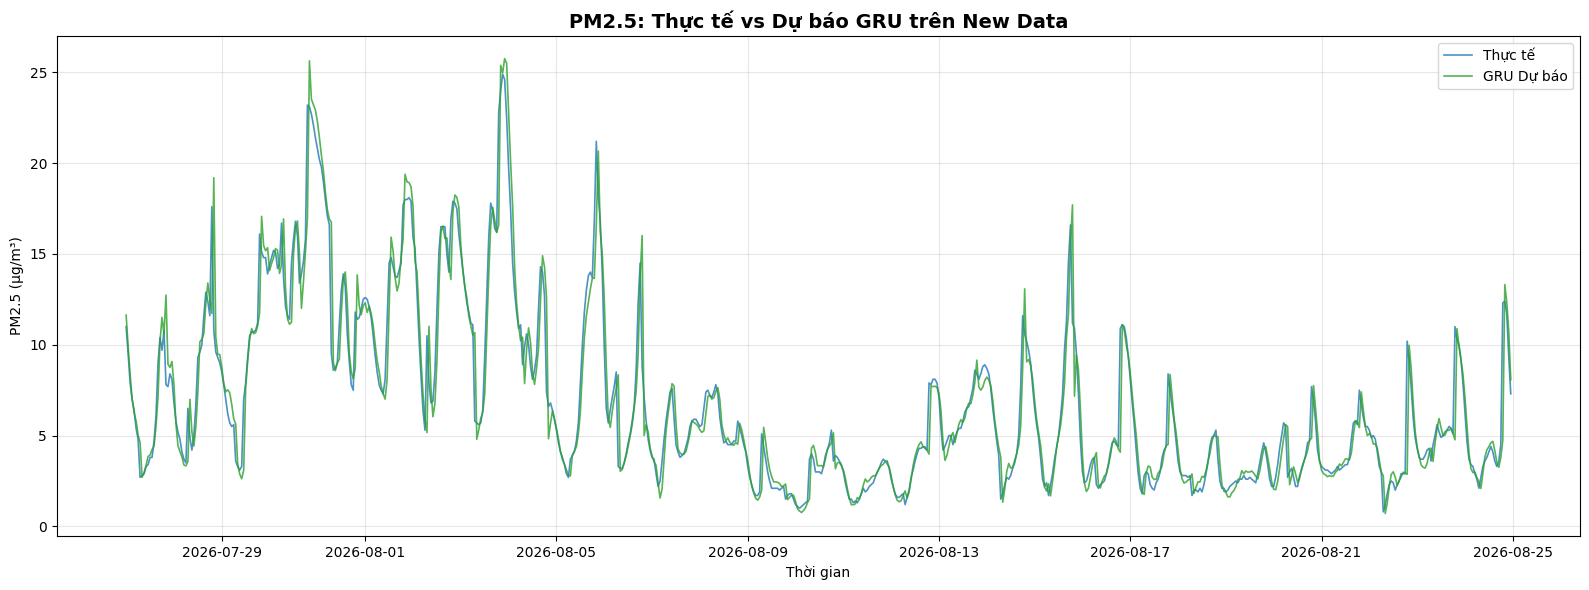

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(target_times_new, true_pm25_new, label='Thực tế', color='#b4511f', alpha=0.8, linewidth=1.2)
plt.plot(target_times_new, pred_pm25_new, label='GRU Dự báo', color='#2ca02c', alpha=0.8, linewidth=1.2)
plt.xlabel('Thời gian')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('PM2.5: Thực tế vs Dự báo GRU trên New Data', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Residual Diagnostics trên New Data

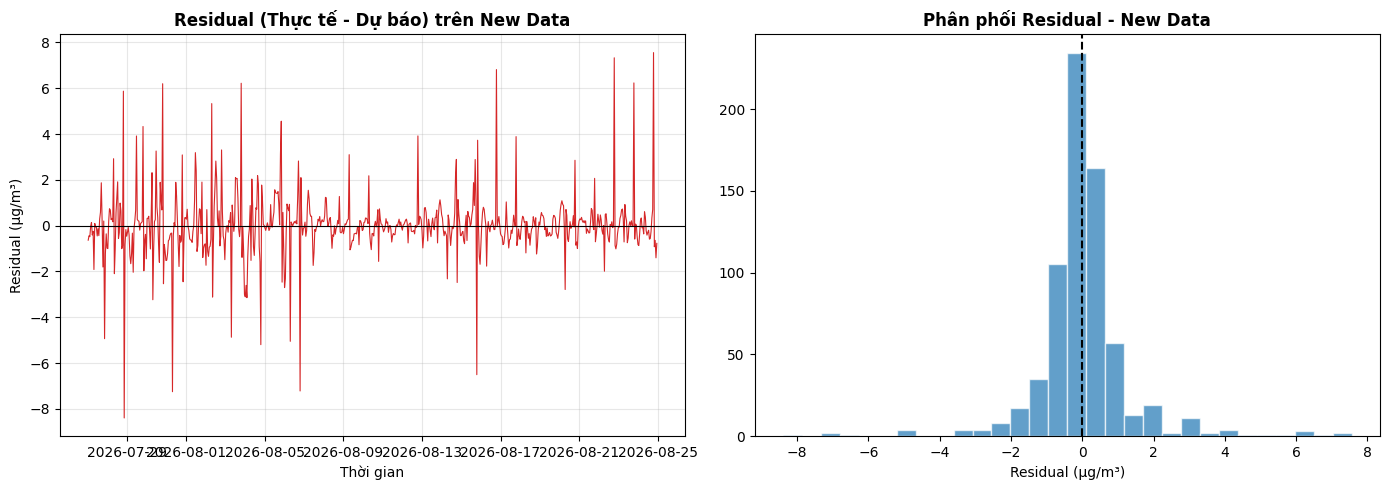

Residual mean: 0.013 µg/m³, std: 1.366 µg/m³


In [15]:
residuals_new = true_pm25_new - pred_pm25_new

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(target_times_new, residuals_new, linewidth=0.8, color='#d62728')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residual (Thực tế - Dự báo) trên New Data', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('Residual (µg/m³)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_new, bins=30, color='#1f77b4', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Phân phối Residual - New Data', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (µg/m³)')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals_new.mean():.3f} µg/m³, std: {residuals_new.std():.3f} µg/m³")